<a href="https://colab.research.google.com/github/Liya-17/DeepFake_Capstone_project/blob/main/Open-Set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/deepfake_openset'

Mounted at /content/drive


In [2]:
!pip install -q --no-deps facenet-pytorch
!pip install -q open_clip_torch opencv-python-headless scikit-learn umap-learn kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [3]:
import numpy, pandas, cv2, torch
from facenet_pytorch import MTCNN
from pathlib import Path
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("All imports OK")

numpy: 2.0.2
pandas: 2.2.2
All imports OK


In [4]:
!mkdir -p /content/raw/ff
!cp -r "{BASE}/ff_subset/." /content/raw/ff/
!ls /content/raw/ff
!find /content/raw/ff -name "*.mp4" | wc -l

Deepfakes  Face2Face  FaceSwap	NeuralTextures	original
1500


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using:", device)
mtcnn = MTCNN(image_size=224, margin=20, post_process=False, device=device)

Using: cuda


In [6]:
import os

def extract_faces(video_path, out_dir, n_frames=12):
    os.makedirs(out_dir, exist_ok=True)
    stem = Path(video_path).stem
    if any(Path(out_dir).glob(f"{stem}_f*.jpg")):
        return "skipped"
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return "unreadable"
    idxs = sorted(set([int(i * total / n_frames) for i in range(n_frames)]))
    saved = 0
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        try:
            face = mtcnn(frame_rgb)
        except Exception:
            continue
        if face is not None:
            out_path = f"{out_dir}/{stem}_f{i}.jpg"
            face_img = face.permute(1, 2, 0).byte().cpu().numpy()
            cv2.imwrite(out_path, cv2.cvtColor(face_img, cv2.COLOR_RGB2BGR))
            saved += 1
    cap.release()
    return saved

In [7]:
manifest = pandas.read_csv(f"{BASE}/raw_manifests/ff_train.csv")

test_rows = manifest.groupby('class_label').head(1)
for _, row in test_rows.iterrows():
    out_dir = f"{BASE}/face_crops/train/{row.class_label}"
    result = extract_faces(row.video_path, out_dir)
    print(row.class_label, result)

real 12
deepfakes 12
face2face 12
faceswap 12
neuraltextures 12


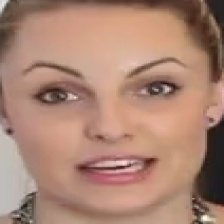

In [8]:
import glob
from PIL import Image
sample = glob.glob(f"{BASE}/face_crops/train/real/*.jpg")[0]
Image.open(sample)

In [9]:
from tqdm import tqdm

results = {"saved": 0, "skipped": 0, "unreadable": 0}
for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    out_dir = f"{BASE}/face_crops/train/{row.class_label}"
    r = extract_faces(row.video_path, out_dir)
    if r == "skipped":
        results["skipped"] += 1
    elif r == "unreadable":
        results["unreadable"] += 1
    else:
        results["saved"] += r

print(results)

100%|██████████| 1500/1500 [2:01:12<00:00,  4.85s/it]

{'saved': 17940, 'skipped': 5, 'unreadable': 0}


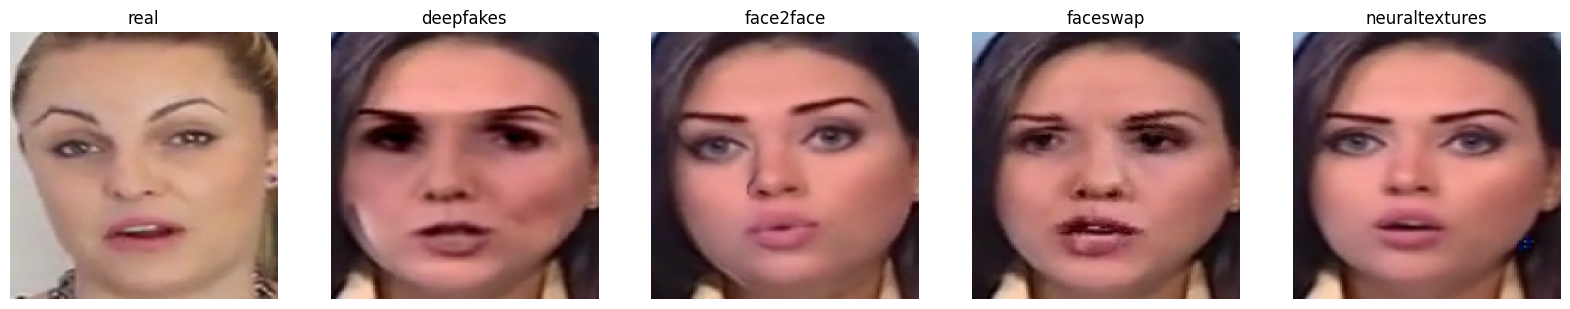

In [10]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

classes = ['real', 'deepfakes', 'face2face', 'faceswap', 'neuraltextures']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, cls in zip(axes, classes):
    sample = glob.glob(f"{BASE}/face_crops/train/{cls}/*.jpg")[10]
    ax.imshow(Image.open(sample))
    ax.set_title(cls)
    ax.axis('off')
plt.show()